In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,  mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import impute
from sklearn import preprocessing
import numpy as np
import warnings
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.decomposition import PCA

In [2]:
file_path = r"D:\Programming\Projects\ai24-toxicity-prediction\data\processed\resultwithfeatures.csv"
df = pd.read_csv(file_path)

C:\Users\Danil\AppData\Local\Temp\ipykernel_9748\1855697575.py:2: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [32]:
df_test = pd.read_csv(file_path)

C:\Users\Danil\AppData\Local\Temp\ipykernel_9748\194602649.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(file_path)


In [33]:
X_test2 = df_test.drop(['LD50', 'Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)

In [34]:
X_test2

,Exp. Animal,Method of administration,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,mouse,intraperitoneal,9.349040,9.349040,0.000000,0.000000,0.692008,14.280000,476.213,452.021,...,0,0,0,0,0,0,0,0,0,0
1,mouse,intraperitoneal,9.564163,9.564163,0.000000,0.000000,0.692008,14.280000,476.213,452.021,...,0,0,0,0,0,0,0,0,0,0
2,mouse,intraperitoneal,9.910675,9.910675,0.000000,0.000000,0.692008,14.280000,476.213,452.021,...,0,0,0,0,0,0,0,0,0,0
3,mouse,intraperitoneal,11.760965,11.760965,0.000000,-0.611197,0.625836,11.041667,419.711,399.551,...,0,0,0,0,0,0,0,0,1,0
4,mouse,intraperitoneal,5.971470,5.971470,0.000000,0.000000,0.176140,11.545455,510.520,474.232,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114752,mouse,intravenous,12.613219,12.613219,0.107125,-2.325406,0.173524,42.046154,924.091,850.507,...,0,0,0,0,0,1,0,0,0,0
114753,mouse,intraperitoneal,12.613219,12.613219,0.107125,-2.325406,0.173524,42.046154,924.091,850.507,...,0,0,0,0,0,1,0,0,0,0
114754,mouse,oral,11.376014,11.376014,0.009406,-1.407863,0.499122,76.631579,380.913,372.849,...,0,1,0,0,0,1,0,0,0,0
114755,mouse,intravenous,14.351329,14.351329,0.000000,-5.319199,0.061101,32.695652,1346.377,1256.665,...,0,0,0,0,1,1,0,0,0,0


In [4]:
df

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114752,PubChem,CC1C=CC=CC=CC=CC=CC=CC=CC(CC2C(C(C[C@](O2)(CC(...,mouse,intravenous,4.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
114753,PubChem,CC1C=CC=CC=CC=CC=CC=CC=CC(CC2C(C(C[C@](O2)(CC(...,mouse,intraperitoneal,88.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
114754,PubChem,C1C(C2C3C1C4[C@@]5([C@@]2(C([C@]3([C@]45Cl)Cl)...,mouse,oral,500.0,mg/kg,NaN,NaN,NaN,NaN,...,0,1,0,0,0,1,0,0,0,0
114755,PubChem,CC1=CC2=C(C=C1C)N(C=N2)C3C(C(C(O3)CO)OP(=O)([O...,mouse,intravenous,2000.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,0,0


In [3]:
df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])
df.shape

(114033, 1422)

In [4]:
df = df.drop(['Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)
df.shape

(114033, 1403)

In [5]:
df = df.dropna(subset=['LD50'])
df.shape

(98512, 1403)

In [6]:
Q10 = df['LD50'].quantile(0.10)
Q90 = df['LD50'].quantile(0.90)
IQR = Q90 - Q10

lower_bound = Q10 - 1.5 * IQR
upper_bound = Q90 + 1.5 * IQR

df = df[(df['LD50'] >= lower_bound) & (df['LD50'] <= upper_bound)]
df = df[df['LD50'] != 0]
df.shape

(95591, 1403)

In [7]:
threshold = 0.996  # Порог в 99.6%
#удаляем столбцы, где 99.6% значений — это одно уникальное значение
def drop_constant_columns(df, threshold):
    to_drop = []  # Список столбцов для удаления
    for col in df.columns:
        # Рассчитываем долю самого частого значения
        max_freq = df[col].value_counts(normalize=True).max()
        if max_freq >= threshold:
            to_drop.append(col)
    # Удаляем столбцы
    return df.drop(columns=to_drop)

# Применяем функцию
df_cleaned = drop_constant_columns(df, threshold)
df = df_cleaned
df.shape

(95591, 1382)

In [8]:
df = df.dropna()
df.shape

(92494, 1382)

In [9]:
df['log_LD50'] = np.log(df['LD50'])
X = df.drop(columns=['LD50', 'log_LD50'])
y = df['log_LD50']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=123)

C:\Users\Danil\AppData\Local\Temp\ipykernel_9748\1465588398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_LD50'] = np.log(df['LD50'])


In [16]:
X

,Exp. Animal,Method of administration,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,mouse,intraperitoneal,9.349040,9.349040,0.000000,0.000000,0.692008,14.280000,476.213,452.021,...,0,0,0,0,0,0,0,0,0,0
1,mouse,intraperitoneal,9.564163,9.564163,0.000000,0.000000,0.692008,14.280000,476.213,452.021,...,0,0,0,0,0,0,0,0,0,0
2,mouse,intraperitoneal,9.910675,9.910675,0.000000,0.000000,0.692008,14.280000,476.213,452.021,...,0,0,0,0,0,0,0,0,0,0
3,mouse,intraperitoneal,11.760965,11.760965,0.000000,-0.611197,0.625836,11.041667,419.711,399.551,...,0,0,0,0,0,0,0,0,1,0
4,mouse,intraperitoneal,5.971470,5.971470,0.000000,0.000000,0.176140,11.545455,510.520,474.232,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114021,mouse,intravenous,15.022344,15.022344,0.036460,-1.947471,0.109538,42.500000,1085.156,1008.548,...,0,0,1,0,0,1,0,0,0,0
114028,mouse,intravenous,12.613219,12.613219,0.107125,-2.325406,0.173524,42.046154,924.091,850.507,...,0,0,0,0,0,1,0,0,0,0
114029,mouse,intraperitoneal,12.613219,12.613219,0.107125,-2.325406,0.173524,42.046154,924.091,850.507,...,0,0,0,0,0,1,0,0,0,0
114030,mouse,oral,11.376014,11.376014,0.009406,-1.407863,0.499122,76.631579,380.913,372.849,...,0,1,0,0,0,1,0,0,0,0


<Axes: >

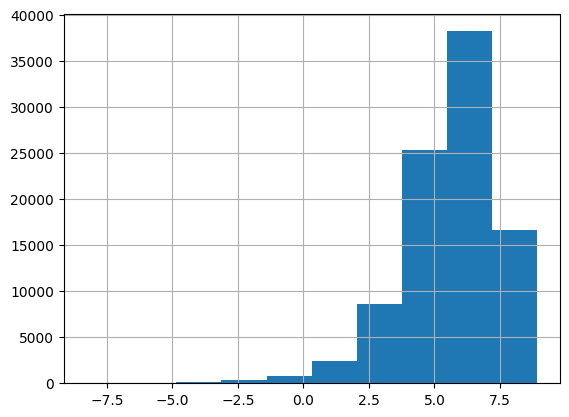

In [15]:
y.hist()

In [10]:
num_col = X.select_dtypes(include=['number']).columns.tolist()
cat_col = X.select_dtypes(include=['object']).columns.tolist()

X_train_cat = X_train[cat_col]
X_train_num = X_train[num_col]

X_test_cat = X_test[cat_col]
X_test_num = X_test[num_col]

In [28]:
numerical_transformer = Pipeline(steps=[
    ("scaler", MinMaxScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop='first')),
])

data_transformer = ColumnTransformer(transformers=[
    ("numerical", numerical_transformer, num_col),
    ("categorical", categorical_transformer, cat_col),
])

preprocessor = Pipeline(steps=[("data_transformer", data_transformer)])

model_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("feature_selector", PCA(n_components=0.95)),
           ("model", LinearRegression())])


In [29]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"r2 на трейне ={r2_score(np.exp(y_train), np.exp(model_pipeline.predict(X_train)))}")
print(f"r2 на тесте ={r2_score(np.exp(y_test), np.exp(y_pred))}")

print(f"MAPE на трейне ={mean_absolute_percentage_error(np.exp(y_train), np.exp(model_pipeline.predict(X_train)))}")
print(f"MAPE на тесте ={mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred))}")

r2 на трейне =0.1341350054209095
r2 на тесте =0.11704943252586653
MAPE на трейне =22.40983143151607
MAPE на тесте =41.56230720980112


In [46]:
model_pipeline[0][0]

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['MaxAbsEStateIndex', 'MaxEStateIndex',
                                  'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
                                  'SPS', 'MolWt', 'HeavyAtomMolWt',
                                  'ExactMolWt', 'NumValenceElectrons',
                                  'MaxPartialCharge', 'MinPartialCharge',
                                  'MaxAbsPartialCharge', 'MinAbsPartialCharge',
                                  'FpDensityMorgan1', 'FpDensityMorgan2',
                                  'FpDensityMorgan3', 'BCUT2D_MWHI',
                                  'BCUT2D_MWLOW', 'BCUT2D_CHGHI',
                                  'BCUT2D_CHGLO', 'BCUT2D_LOGPHI',
                                  'BCUT2D_LOGPLOW', 'BCUT2D_MRHI',
                                  'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ',
                                  'BertzCT', 'Chi0', 'Chi0n', ...]),
                                ('categorical',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Exp. Animal', 'Method of administration'])])

(array([  2.,   7.,  29.,  79., 132., 224., 170., 106.,  33.,  10.]),
 array([-0.59724632, -0.49244385, -0.38764138, -0.28283891, -0.17803645,
        -0.07323398,  0.03156849,  0.13637096,  0.24117343,  0.3459759 ,
         0.45077837]),
 <BarContainer object of 10 artists>)

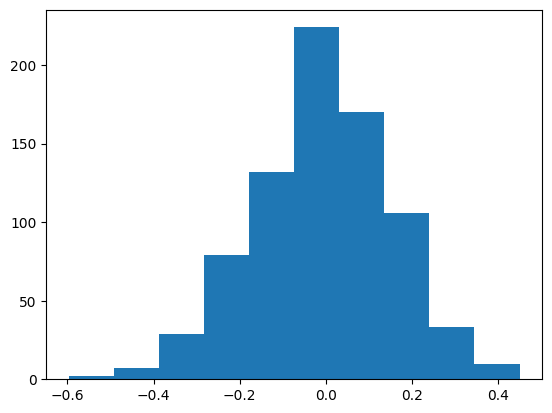

In [31]:
plt.hist(model_pipeline[2].coef_)

In [40]:
np.exp(model_pipeline.predict(X_test2[:1]))

array([396.69188155])

In [39]:
df_test

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114752,PubChem,CC1C=CC=CC=CC=CC=CC=CC=CC(CC2C(C(C[C@](O2)(CC(...,mouse,intravenous,4.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
114753,PubChem,CC1C=CC=CC=CC=CC=CC=CC=CC(CC2C(C(C[C@](O2)(CC(...,mouse,intraperitoneal,88.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,1,0,0,0,0
114754,PubChem,C1C(C2C3C1C4[C@@]5([C@@]2(C([C@]3([C@]45Cl)Cl)...,mouse,oral,500.0,mg/kg,NaN,NaN,NaN,NaN,...,0,1,0,0,0,1,0,0,0,0
114755,PubChem,CC1=CC2=C(C=C1C)N(C=N2)C3C(C(C(O3)CO)OP(=O)([O...,mouse,intravenous,2000.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,0,0


In [41]:
# Для сериализации моделей
import pickle

with open("pipeline_model.pkl", "wb") as f:
    pickle.dump(model_pipeline, f)